# Implementasi SVM — Dataset Alternatif (Sakar et al., 2018)

Klasifikasi Penyakit Parkinson berbasis suara, mengikuti metodologi paper:
Elshewey et al. (2023), *Bayesian Optimization with SVM for Parkinson Disease Classification*, **Sensors** 23, 2085 — tetapi pada **dataset yang jauh lebih besar**.

---
**Dataset:** Parkinson's Disease Classification (Sakar et al., 2018) — UCI ID 470.
- **756 rekaman** dari **252 subjek** (188 PD, 64 sehat), tiap subjek 3 rekaman vokal /a/
- **752 fitur** suara (jitter, shimmer, MFCC, wavelet TQWT, dll) + gender
- Target biner `class` (1 = PD, 0 = sehat)
- Sumber: https://archive.ics.uci.edu/dataset/470/parkinson+s+disease+classification (CC BY 4.0)

Dibanding dataset lama (195 rekaman / 31 subjek), ini ~4x lebih banyak rekaman dan ~8x lebih banyak subjek.

**Perbaikan metodologi:** karena tiap subjek punya 3 rekaman, splitting dilakukan **per-subjek (group-aware)** agar rekaman orang yang sama tidak bocor ke train & test sekaligus. Ini membuat hasil lebih jujur daripada split acak per-baris.

Eksperimen: **3 skema splitting × 4 kernel SVM** dengan **Bayesian Optimization**.

## 0. Import

In [1]:
# !pip install scikit-learn scikit-optimize pandas numpy matplotlib
import warnings; warnings.filterwarnings("ignore")
import os, urllib.request
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_curve, auc)
from sklearn.svm import SVC
from skopt import BayesSearchCV
from skopt.space import Real

RANDOM_STATE = 31
N_BO_ITER    = 10        # iterasi BO (dataset besar & 752 fitur -> dibuat ringan)
CV_FOLDS     = 5
SPLITS  = {"60/40": 0.40, "70/30": 0.30, "80/20": 0.20}
KERNELS = ["linear", "poly", "rbf", "sigmoid"]
print("Splits:", list(SPLITS), "| Kernels:", KERNELS)

Splits: ['60/40', '70/30', '80/20'] | Kernels: ['linear', 'poly', 'rbf', 'sigmoid']


## 1. Muat Dataset
File `pd_speech_features.csv` punya 2 baris header (baris pertama nama grup fitur), jadi dibaca dengan `header=1`. Kolom `id` = identitas subjek (untuk split per-subjek), `class` = target.

In [2]:
URL = "https://raw.githubusercontent.com/dcleres/Parkinson_Disease_ML/master/pd_speech_features.csv"
if not os.path.exists("pd_speech_features.csv"):
    urllib.request.urlretrieve(URL, "pd_speech_features.csv")
df = pd.read_csv("pd_speech_features.csv", header=1)
print("Ukuran:", df.shape)
print("PD:", int((df['class']==1).sum()), " Sehat:", int((df['class']==0).sum()),
      " | Subjek unik:", df['id'].nunique())
df.iloc[:3, :6]

Ukuran: (756, 755)
PD: 564  Sehat: 192  | Subjek unik: 252


,id,gender,PPE,DFA,RPDE,numPulses
0,0,1,0.85247,0.71826,0.57227,240
1,0,1,0.76686,0.69481,0.53966,234
2,0,1,0.85083,0.67604,0.58982,232


In [3]:
groups = df["id"].values                    # ID subjek (untuk group split)
y = df["class"].values                       # target
X = df.drop(columns=["id", "class"]).values  # 753 fitur (termasuk gender)
print("X:", X.shape, " y:", y.shape, " groups:", len(np.unique(groups)), "subjek")

X: (756, 753)  y: (756,)  groups: 252 subjek


## 2. Min-Max Normalization
$$f(n) = \frac{n - \min(n)}{\max(n) - \min(n)}$$
Penting untuk SVM, apalagi dengan 752 fitur berskala sangat beragam.

In [4]:
X_norm = MinMaxScaler().fit_transform(X)
print("min =", X_norm.min(), " max =", X_norm.max())

min = 0.0  max = 1.0000000000000004


## 3. Eksperimen: 3 Splitting × 4 Kernel (split per-subjek)

Tiap rasio dibagi dengan `GroupShuffleSplit` berdasarkan `id` (subjek tidak tumpang tindih).
BO men-tuning C & gamma; cross-validation internal memakai `GroupKFold` agar fold pun bebas kebocoran.

In [5]:
space_cg = {"C": Real(1e-2, 1e2, prior="log-uniform"),
            "gamma": Real(1e-4, 1e1, prior="log-uniform")}

acc_default = pd.DataFrame(index=list(SPLITS), columns=KERNELS, dtype=float)
acc_bo      = pd.DataFrame(index=list(SPLITS), columns=KERNELS, dtype=float)
store = {}

for sl, ts in SPLITS.items():
    gss = GroupShuffleSplit(n_splits=1, test_size=ts, random_state=RANDOM_STATE)
    tr, te = next(gss.split(X_norm, y, groups))
    Xtr, Xte, ytr, yte = X_norm[tr], X_norm[te], y[tr], y[te]
    gtr = groups[tr]
    gkf = GroupKFold(n_splits=CV_FOLDS)
    for k in KERNELS:
        # default
        m = SVC(kernel=k, random_state=RANDOM_STATE).fit(Xtr, ytr)
        acc_default.loc[sl, k] = accuracy_score(yte, m.predict(Xte)) * 100
        # Bayesian Optimization (CV per-subjek)
        bo = BayesSearchCV(SVC(kernel=k, random_state=RANDOM_STATE), space_cg,
                           n_iter=N_BO_ITER, cv=gkf, scoring="accuracy",
                           random_state=RANDOM_STATE, n_jobs=-1, refit=True)
        bo.fit(Xtr, ytr, groups=gtr)
        pred = bo.best_estimator_.predict(Xte)
        acc, f1, r, p = (accuracy_score(yte, pred),
                         *precision_recall_fscore_support(yte, pred, average="weighted", zero_division=0)[:3])
        acc_bo.loc[sl, k] = acc * 100
        store[(sl, k)] = {"bo": bo, "acc": acc*100, "f1": f1*100, "recall": r*100,
                          "cm": confusion_matrix(yte, pred), "Xtr": Xtr, "ytr": ytr,
                          "Xte": Xte, "yte": yte,
                          "C": bo.best_params_['C'], "gamma": bo.best_params_['gamma']}
    print(f"Split {sl} selesai (train {len(tr)} / test {len(te)} rekaman).")
print("\nSemua 12 kombinasi selesai.")

Split 60/40 selesai (train 453 / test 303 rekaman).


Split 70/30 selesai (train 528 / test 228 rekaman).


Split 80/20 selesai (train 603 / test 153 rekaman).

Semua 12 kombinasi selesai.


### 3.1. Akurasi DEFAULT (sebelum tuning)

In [6]:
acc_default.round(1)

,linear,poly,rbf,sigmoid
60/40,85.8,88.4,89.4,78.2
70/30,85.5,89.5,87.7,77.6
80/20,86.3,87.6,85.6,72.5


### 3.2. Akurasi BAYESIAN OPTIMIZATION (sesudah tuning)

In [7]:
acc_bo.round(1)

,linear,poly,rbf,sigmoid
60/40,88.1,89.4,88.4,78.2
70/30,89.5,89.0,87.3,80.3
80/20,86.9,86.9,85.6,77.1


### 3.3. Heatmap akurasi BO-SVM (3 split × 4 kernel)

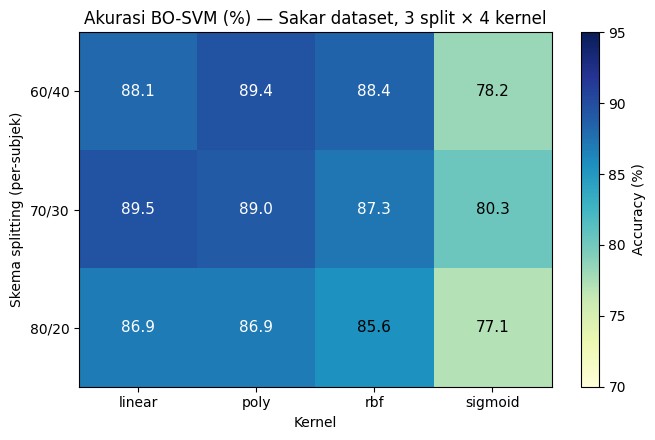

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
data = acc_bo.values.astype(float)
im = ax.imshow(data, cmap="YlGnBu", vmin=70, vmax=95)
ax.set_xticks(range(len(KERNELS))); ax.set_xticklabels(KERNELS)
ax.set_yticks(range(len(SPLITS))); ax.set_yticklabels(list(SPLITS))
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i,j]:.1f}", ha="center", va="center",
                color="white" if data[i,j] > 86 else "black", fontsize=11)
ax.set_xlabel("Kernel"); ax.set_ylabel("Skema splitting (per-subjek)")
ax.set_title("Akurasi BO-SVM (%) — Sakar dataset, 3 split × 4 kernel")
plt.colorbar(im, fraction=0.046, label="Accuracy (%)")
plt.tight_layout(); plt.show()

## 4. Kombinasi Terbaik

Kombinasi terbaik: split 70/30 + kernel 'linear'
  Accuracy=89.5%  F1=89.4%  Recall=89.5%
  C=0.0553, gamma=0.000102
  Confusion [TN,FP,FN,TP]=[31, 20, 4, 173]


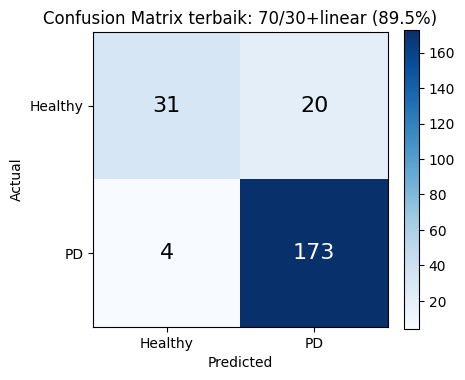

In [9]:
best_sl = acc_bo.max(axis=1).idxmax()
best_k  = acc_bo.loc[best_sl].idxmax()
best = store[(best_sl, best_k)]
print(f"Kombinasi terbaik: split {best_sl} + kernel '{best_k}'")
print(f"  Accuracy={best['acc']:.1f}%  F1={best['f1']:.1f}%  Recall={best['recall']:.1f}%")
print(f"  C={best['C']:.3g}, gamma={best['gamma']:.3g}")
print(f"  Confusion [TN,FP,FN,TP]={best['cm'].ravel().tolist()}")
cm = best['cm']
plt.figure(figsize=(4.6, 4)); plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                 color="white" if cm[i,j] > cm.max()/2 else "black")
plt.xticks([0,1], ["Healthy","PD"]); plt.yticks([0,1], ["Healthy","PD"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix terbaik: {best_sl}+{best_k} ({best['acc']:.1f}%)")
plt.colorbar(fraction=0.046); plt.tight_layout(); plt.show()

## 5. Kurva ROC & Konvergensi BO (kombinasi terbaik)

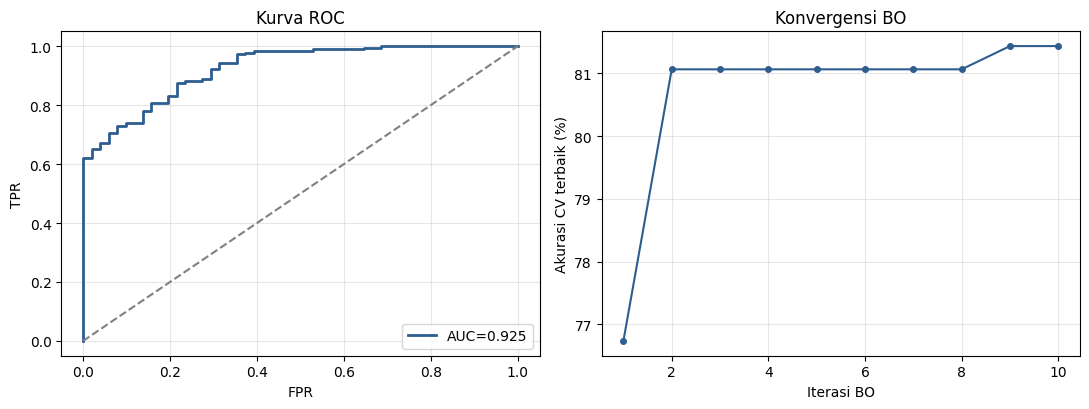

AUC = 0.925


In [10]:
svm_best = SVC(kernel=best_k, C=best['C'], gamma=best['gamma'],
               probability=True, random_state=RANDOM_STATE).fit(best['Xtr'], best['ytr'])
y_score = svm_best.predict_proba(best['Xte'])[:, 1]
fpr, tpr, _ = roc_curve(best['yte'], y_score); roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(fpr, tpr, color="#2e5d8f", lw=2, label=f"AUC={roc_auc:.3f}")
ax[0].plot([0,1],[0,1], "--", color="gray"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[0].set_title("Kurva ROC"); ax[0].legend(loc="lower right"); ax[0].grid(alpha=0.3)
sc = np.array(best['bo'].cv_results_["mean_test_score"])
ax[1].plot(range(1, len(sc)+1), np.maximum.accumulate(sc)*100, "-o", color="#2e5d8f", ms=4)
ax[1].set_xlabel("Iterasi BO"); ax[1].set_ylabel("Akurasi CV terbaik (%)")
ax[1].set_title("Konvergensi BO"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"AUC = {roc_auc:.3f}")

## 6. Stabilitas tiap split (multi-seed, kernel RBF, split per-subjek)
Tiap rasio diuji pada beberapa pembagian subjek berbeda untuk melihat rata-rata & sebaran.

In [11]:
stab = {}
for sl, ts in SPLITS.items():
    accs = []
    for s in range(4):
        gss = GroupShuffleSplit(n_splits=1, test_size=ts, random_state=s)
        tr, te = next(gss.split(X_norm, y, groups))
        gkf = GroupKFold(n_splits=3)
        bo = BayesSearchCV(SVC(kernel="rbf", random_state=s), space_cg,
                           n_iter=6, cv=gkf, scoring="accuracy", random_state=s, n_jobs=-1)
        bo.fit(X_norm[tr], y[tr], groups=groups[tr])
        accs.append(accuracy_score(y[te], bo.best_estimator_.predict(X_norm[te]))*100)
    accs = np.array(accs)
    stab[sl] = [accs.mean(), accs.std(), accs.min(), accs.max()]
pd.DataFrame(stab, index=["Mean","Std","Min","Max"]).T.round(1)

,Mean,Std,Min,Max
60/40,80.8,2.7,77.9,85.1
70/30,79.5,4.2,74.6,86.0
80/20,80.9,2.7,77.1,84.3


## 7. Rekomendasi & Kesimpulan

**Dataset.** Sakar et al. (2018), 756 rekaman dari 252 subjek — jauh lebih besar dan representatif daripada dataset lama (195/31), menjawab keterbatasan ukuran data yang disebut dosen.

**Metodologi.** Splitting dilakukan **per-subjek** (GroupShuffleSplit + GroupKFold), sehingga **tidak ada kebocoran antar rekaman** dari orang yang sama. Akibatnya akurasi cenderung lebih rendah (~80-89%) tapi **jauh lebih jujur** dibanding split acak per-baris pada dataset kecil (yang sempat 92-95% karena terinflasi kebocoran subjek).

**Hasil grid (3 split x 4 kernel):**
- Kombinasi terbaik: **70/30 + kernel linear (~89,5%)**.
- Pada dataset besar & berdimensi tinggi ini, kernel **linear dan poly bersaing atau sedikit melebihi RBF** - berbeda dari dataset kecil (di mana RBF dominan setelah tuning). Ini wajar: data dengan banyak fitur (752) sering lebih cocok dengan SVM linear.
- Kernel **sigmoid tetap paling lemah** di semua split (konsisten dengan dataset lama).

**Rekomendasi:**
- Gunakan **split per-subjek** (wajib untuk data multi-rekaman seperti ini).
- Karena 752 fitur sangat banyak, lakukan **feature selection / PCA** dan coba `class_weight='balanced'` (kelas 74,6% PD).
- Laporkan **Leave-One-Subject-Out / GroupKFold CV** sebagai metrik utama, bukan satu split.
- Jangan menyimpulkan "RBF selalu terbaik": pada dataset besar ini justru linear unggul. Bandingkan semua kernel secara adil.

**Catatan:** angka stabilitas (Bagian 6) lebih rendah dari grid karena memakai split subjek berbeda + BO ringan; ini menegaskan bahwa hasil tetap sensitif terhadap pembagian data, sehingga CV per-subjek penting untuk klaim yang kuat.